# Project Fast R-CNN: Object Detection on Raccoon Dataset
In this project, I implement a Fast Region-based Convolutional Neural Network (Fast R-CNN) for detecting raccoons in images using PyTorch.

## Data
[Raccoon dataset](https://public.roboflow.com/object-detection/raccoon/38): 196 images with bounding box annotations

Format: YOLO/Pascal VOC (download from Roboflow)

## Materials

- [Original paper](https://arxiv.org/pdf/1311.2524)
- [Simplified explanation](https://towardsdatascience.com/r-cnn-fast-r-cnn-faster-r-cnn-yolo-object-detection-algorithms-36d53571365e/)
- [Selective search](https://learnopencv.com/selective-search-for-object-detection-cpp-python/)
- [PyTorch Object Detection Finetuning](https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html)
- [Non-Maximum Suppression (NMS)](https://thepythoncode.com/article/non-maximum-suppression-using-opencv-in-python)

## Task
**1. Data Analysis & Preparation **

- Calculate basic statistics: image sizes, aspect ratios, box count per image
- Visualize data: Plot distribution of bounding box sizes/locations
- Create train/test(/val) splits

**2. Model Implementation **

- Selective search integration (with [selectivesearch](https://github.com/AlpacaTechJP/selectivesearch?tab=readme-ov-file) library)
- Integration pre-trained backbone
- Implement classification head (raccoon/background)
- Implement bounding box regression head
- Implement IoU calculation and NMS

**3. Training & Evaluation **

- Set up data loader with proper batching
- Train for N epochs with validation
- Compare with PyTorch realization (Optional)


**4. Conclusions **





###  Data Analysis & Preparation

In [ ]:
!pip install roboflow
!pip install selectivesearch

In [2]:
from roboflow import Roboflow
from torch.utils.data import Dataset
import selectivesearch
from PIL import Image
import numpy as np
import random
from torchvision.transforms import ToTensor
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Uploading data in yolo format
rf = Roboflow(api_key="8GE1PtefNMJn3MUBZrs3")
project = rf.workspace("roboflow-gw7yv").project("raccoon")
version = project.version(38)
dataset = version.download("yolov7")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Raccoon-38 in yolov7pytorch:: 100%|██████████| 799/799 [00:00<00:00, 5197.59it/s]


In [4]:
import os
import cv2
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import patches
'''
Markup extraction and label analysis below
'''
img_dir = 'Raccoon-38/train/images'
label_dir = 'Raccoon-38/train/labels'

img_sizes = []
aspect_ratios = []
box_counts = []
x_center = []
y_center = []
width = []
height = []

for img_file in os.listdir(img_dir):

    if img_file.endswith('.jpg') or img_file.endswith('.png'):

        img_path = os.path.join(img_dir, img_file)
        label_path = os.path.join(label_dir, img_file.replace('.jpg', '.txt').replace('.png', '.txt'))
        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        img_sizes.append((w, h))
        aspect_ratios.append(w / h)

        if os.path.exists(label_path):

            with open(label_path) as f:

                lines = f.readlines()
                for i in lines:
                  a = i.split()
                  x_center.append(float(a[1]))
                  y_center.append(float(a[2]))
                  width.append(float(a[3]))
                  height.append(float(a[4]))
                box_counts.append(len(lines))
        else:
            box_counts.append(0)

In [5]:
print('Box count per image',Counter(box_counts))
print('Aspect ratios',Counter(aspect_ratios))
print('image sizes',Counter(img_sizes))           # all imgs are the same size

Box count per image Counter({1: 137, 2: 12, 3: 1})
Aspect ratios Counter({1.0: 150})
image sizes Counter({(416, 416): 150})


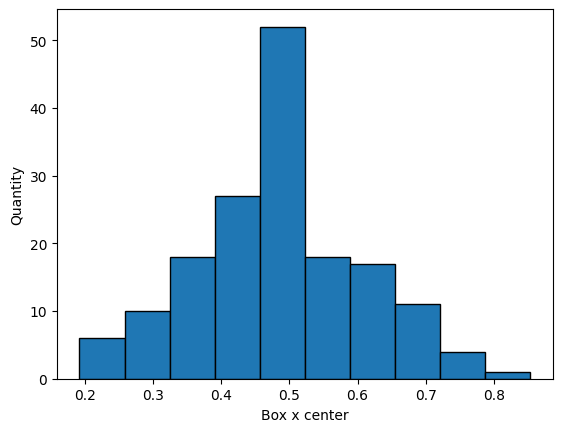

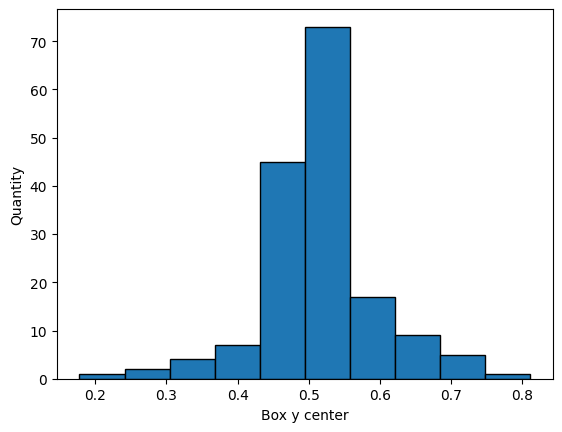

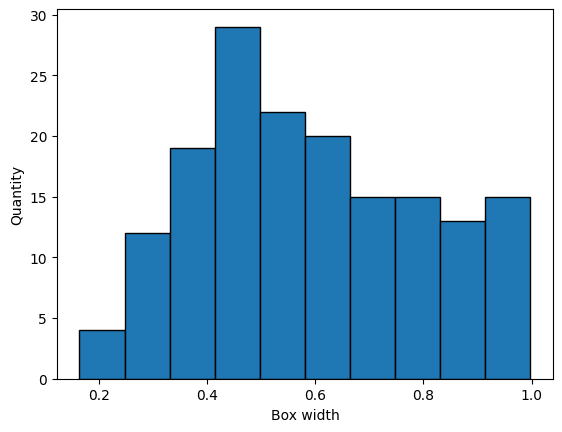

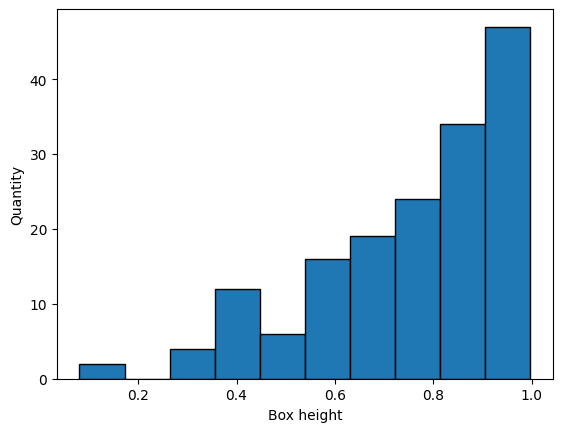

In [6]:
plt.hist(x_center,bins = 10,edgecolor='black')
plt.xlabel('Box x center')
plt.ylabel('Quantity')
plt.show()

plt.hist(y_center,bins = 10,edgecolor='black')
plt.xlabel('Box y center')
plt.ylabel('Quantity')
plt.show()

plt.hist(width,bins = 10,edgecolor='black')
plt.xlabel('Box width')
plt.ylabel('Quantity')
plt.show()

plt.hist(height,bins = 10,edgecolor='black')
plt.xlabel('Box height')
plt.ylabel('Quantity')
plt.show()

### Model Implementation

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from selectivesearch import selective_search

In [8]:
import albumentations as A  # for augmentation

class RaccoonDataset(Dataset):
    def __init__(self,
                 data_type = 'train',
                 ss_scale = 250,
                 ss_sigma = 0.6,
                 ss_minsize = 30,
                 augment = True,
                 num_proposals = 1000
                 ):

        self.scale = ss_scale
        self.sigma = ss_sigma
        self.min_size = ss_minsize

        self.num_proposals = num_proposals  # number of regions of interest (RoIs)
        self.root = f'Raccoon-38/{data_type}/'
        self.imgs = list(sorted(os.listdir(self.root+'images')))  # pathes of imgs
        self.get_impath = lambda x: f"{self.root}/images/{self.imgs[x][:-4]}.jpg"  # return path by index


        self.augment = augment

        if self.augment:
            self.transform = A.Compose(
                [
                    A.HorizontalFlip(p=0.5),
                    A.RandomBrightnessContrast(0.3, 0.3, p=0.5),
                    A.ColorJitter(0.2, 0.2, 0.2, 0.1, p=0.75),
                    A.GaussianBlur(blur_limit=5, sigma_limit=(0.3, 1), p=0.3)
                ],
                bbox_params=A.BboxParams(format="pascal_voc")
            )
        else:
            self.transform = None

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):

        image_id = self.imgs[idx][:-4]
        image_path = self.get_impath(idx)
        boxes_path = f'{self.root}/labels/{image_id}.txt'
        image = cv2.imread(image_path)   # get image as numpy
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        height, width = image.shape[:2]

        with open(boxes_path) as f:   # Get ground truth boxes
          gt_boxes = []

          for i in f.readlines():     # Формат разметки: (x, y, w, h)
            b = [float(j) for j in i.split()]
            b[1] -=b[3]/2
            b[2] -=b[4]/2
            b[3] +=b[1]
            b[4] +=b[2]
            gt_boxes.append(b)   # Формат боксов x1, y1, x2, y2
        gt_boxes = torch.tensor(gt_boxes, dtype = torch.float32)*image.shape[0]  # convert to torch.tensor
        gt_boxes = gt_boxes[:,1:]   # ridding of the first index

        # augmentation
        if self.transform and len(gt_boxes):
            res = self.transform(image=image, bboxes=gt_boxes.numpy())
            image, gt_boxes = res["image"], torch.as_tensor(res["bboxes"], dtype=torch.float32)

        # Generate proposals with selective search
        _, regions = selective_search(image, scale=self.scale, sigma = self.sigma, min_size=self.min_size)
        proposals = []
        for r in regions:
            x1, y1, w, h = r['rect']
            if w>20 and h>20:
              proposals.append([x1, y1, x1+w, y1+h])

        # Convert to numpy array and limit number of proposals
        proposals = np.array(proposals[:self.num_proposals])

        # Compute IoUs and create targets
        ious = self.compute_ious(proposals, gt_boxes)
        max_ious = ious.max(axis=1)

        # Assign labels for raccoon and background by threshold
        labels = (max_ious >= 0.5).astype(np.int64)

        # Compute regression targets only for positive samples
        deltas = np.zeros((len(proposals), 4), dtype=np.float32)
        pos_indices = np.where(max_ious >= 0.3)[0]

        if len(pos_indices) > 0:
            best_gt_indices = ious[pos_indices].argmax(axis=1)
            best_gt_boxes = gt_boxes[best_gt_indices]
            deltas[pos_indices] = self.compute_deltas(proposals[pos_indices], best_gt_boxes)

        return image, {
            'proposals': torch.FloatTensor(proposals),
            'labels': torch.LongTensor(labels),
            'deltas': torch.FloatTensor(deltas),
            'gt_boxes': torch.FloatTensor(gt_boxes)
        }

    def compute_ious(self, boxes1, boxes2):
        #Compute IoU matrix between two sets of boxes
        ious = np.zeros((len(boxes1), len(boxes2)))

        for i, box1 in enumerate(boxes1):
            for j, box2 in enumerate(boxes2):
                ious[i,j] = self.compute_iou(box1, box2)

        return ious

    def compute_iou(self, box1, box2):
        #Compute Intersection over Union for two boxes
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection = max(0, x2 - x1) * max(0, y2 - y1)

        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

        union = area1 + area2 - intersection

        return intersection / (union + 1e-6)

    def compute_deltas(self, proposals, gt_boxes):
        #Compute regression deltas (dx, dy, dw, dh)
        proposals_cx = (proposals[:, 0] + proposals[:, 2]) / 2
        proposals_cy = (proposals[:, 1] + proposals[:, 3]) / 2
        proposals_w = proposals[:, 2] - proposals[:, 0]
        proposals_h = proposals[:, 3] - proposals[:, 1]

        gt_cx = (gt_boxes[:, 0] + gt_boxes[:, 2]) / 2
        gt_cy = (gt_boxes[:, 1] + gt_boxes[:, 3]) / 2
        gt_w = gt_boxes[:, 2] - gt_boxes[:, 0]
        gt_h = gt_boxes[:, 3] - gt_boxes[:, 1]

        dx = (gt_cx - proposals_cx) / proposals_w
        dy = (gt_cy - proposals_cy) / proposals_h
        dw = np.log(gt_w / proposals_w)
        dh = np.log(gt_h / proposals_h)

        return np.stack([dx, dy, dw, dh], axis=1)


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from torchvision.ops import roi_align

class FastRCNN(nn.Module):
    def __init__(self, roi_size = (7,7), spatial_scale = 1/32,):
        super().__init__()
        self.roi_size = roi_size
        self.spatial_scale = spatial_scale
        # -------------------------------------------------
        '''
        backbone = models.vgg16(pretrained=True)  # backbone making feature map from initial image
        self.features = backbone.features
        feat_dim = 512 * roi_size[0] * roi_size[1]
        self.spatial_scale = 1/16
        # Freeze some layers
        for layer in list(self.features.children())[:-2]:
            for param in layer.parameters():
                param.requires_grad = False
        '''
        # -------------------------------------------------

        backbone = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="COCO_V1").backbone
        backbone.to('cuda')

        #features = backbone(x)  # features — dict: {'0': ..., '1': ..., ...}
        #for k, v in features.items():
        #    print(k, v.shape)
        for layer in list(backbone.children()): # Теперь итерируем по детям backbone
            for param in layer.parameters():
                param.requires_grad = False

        dummy = torch.randn(1, 3, 416, 416).to('cuda')
        self.features = lambda x: backbone(x)['2']
        out = self.features(dummy)
        feat_dim = out.shape[1] * roi_size[0] * roi_size[1]
        stride = dummy.shape[2] // out.shape[2]
        self.spatial_scale = 1 / stride
        print('stride:',stride)

        # -------------------------------------------------




        hidden = 1024
        # Classification head (енот/фон)
        self.cls_head = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.ReLU(), #nn.Dropout(0.5),
            nn.Linear(hidden, hidden), nn.ReLU(), #nn.Dropout(0.5),
            nn.Linear(hidden, 1)
        )

        # Bounding box regression head
        self.reg_head = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.ReLU(), #nn.Dropout(0.5),
            nn.Linear(hidden, hidden), nn.ReLU(),# nn.Dropout(0.5),
            nn.Linear(hidden, 4)
        )

    def forward(self, x, proposals):
        features = self.features(x)  # [B, C, H, W]

        # convert proposals to rois torch tensor
        rois = []
        for i, props in enumerate(proposals):
            idx_col = torch.full((len(props), 1), i, dtype=props.dtype,
                                 device=props.device)
            rois.append(torch.cat([idx_col, props], dim=1))  # (batch, x1,y1,x2,y2)
        rois = torch.cat(rois, dim=0)                 # [M, 5]

        # ROI Align
        pooled = roi_align(features, rois,
                           output_size=self.roi_size,
                           spatial_scale=self.spatial_scale,
                           sampling_ratio=2,
                           aligned=True)              # [M, 512, 7, 7]
        pooled = pooled.flatten(1)

        cls_logits = self.cls_head(pooled).squeeze(1) # [M]
        reg_delta  = self.reg_head(pooled)            # [M,4]
        return cls_logits, reg_delta



    @staticmethod
    def loss_fn(cls_logits, reg_delta, labels, deltas):
        labels = torch.cat(labels).float().to(cls_logits.device)   # [M]
        deltas = torch.cat(deltas).to(cls_logits.device)           # [M,4]

        cls_loss = F.binary_cross_entropy_with_logits(cls_logits, labels)

        pos = labels.bool()
        reg_loss = (F.smooth_l1_loss(reg_delta[pos], deltas[pos])
                    if pos.any()
                    else torch.tensor(0., device=cls_logits.device))

        total = cls_loss + 10 * reg_loss           # λ=10 — как в Fast R-CNN
        return total, cls_loss, reg_loss



### Dataset class checking

Train Dataset length: 150
proposals torch.Size([298, 4])
deltas tensor([ 0.4762,  0.2024,  0.5482, -0.1603])
tensor(0.3513) tensor(0.7089) tensor(0.3831) tensor(0.4706) tensor(0.4706) tensor(0.5199) tensor(0.4120) tensor(0.5890) tensor(0.3513) tensor(0.3513) 


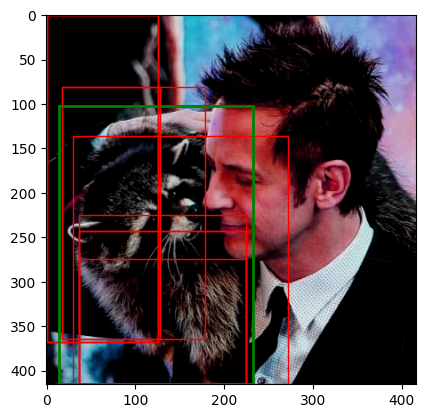

In [10]:
# demonstration of ground truth regions and proposal regions
def test_dataset():
  dataset = RaccoonDataset(
      ss_scale = 250,
      ss_sigma = 0.6,
      ss_minsize = 30
  )  # allows to visually fit selective_search params
  print('Train Dataset length:',len(dataset))
  n = random.randint(0,100)
  #n = 0
  image,targets = dataset[n]

  fig,ax = plt.subplots(1)
  ax.imshow(image)

  k,i = 0,-1
  while k<10 and i!=len(targets['proposals'])-1:
    i+=1

    box = targets['proposals'][i]
    if dataset.compute_iou(box,targets['gt_boxes'][0])<=0.3:
      continue
    k+=1

    if k == 1:
      print('proposals',targets['proposals'].shape)
      print('deltas',targets['deltas'][i])

    print(dataset.compute_iou(box,targets['gt_boxes'][0]),end = ' ')
    x1,y1,x2,y2 = box
    rect = patches.Rectangle((x1,y1),x2-x1,y2-y1,linewidth = 1,edgecolor = 'r',facecolor='none')
    ax.add_patch(rect)
  print()

  for box in targets['gt_boxes']:
    x1,y1,x2,y2 = box
    rect = patches.Rectangle((x1,y1),x2-x1,y2-y1,linewidth = 2,edgecolor = 'g',facecolor='none')
    ax.add_patch(rect)
  plt.show()

test_dataset()

### Training & Evaluation

In [11]:
from torchvision.ops import nms

def train_batch(model, batch, optimizer, device='cuda'):
    """
    batch  = (imgs, props, labels, deltas)
    imgs   : Tensor[B,3,H,W]
    props  : list[Tensor[N_i,4]]  (ROI в пикселях)
    labels : list[Tensor[N_i]]    (0/1)
    deltas : list[Tensor[N_i,4]]
    """
    model.train()
    imgs, props, labels, deltas = batch
    imgs   = imgs.to(device)
    props  = [p.to(device) for p in props]

    cls_logits, reg_delta = model(imgs, props)
    loss, cls_l, reg_l    = model.loss_fn(cls_logits, reg_delta,
                                          labels, deltas)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item(), cls_l.item(), reg_l.item()

# validation func
@torch.no_grad()
def validate_batch(model, batch, device='cuda'):
    model.eval()
    imgs, props, labels, deltas = batch
    imgs  = imgs.to(device)
    props = [p.to(device) for p in props]

    cls_logits, reg_delta = model(imgs, props)
    loss, cls_l, reg_l    = model.loss_fn(cls_logits, reg_delta,
                                          labels, deltas)
    return loss.item(), cls_l.item(), reg_l.item()


@torch.no_grad()
def predict(image_path,
            model,
            topk_props=1000,
            score_th=0.5,
            iou_th=0.3,
            device='cuda',
            ds = RaccoonDataset()):
    """
    Возвращает:
      boxes  – np.ndarray [K,4] (x1,y1,x2,y2) в пикселях
      scores – np.ndarray [K]   (0..1)
    """
    model.eval()

    # ---------- загрузка изображения ----------
    bgr = cv2.imread(image_path)
    if bgr is None:
        raise FileNotFoundError(image_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    H, W = rgb.shape[:2]

    # ---------- селективный серч ----------
    _, regions = selective_search(rgb, scale=ds.scale, sigma=ds.sigma, min_size=ds.min_size)
    props = [[x, y, x + w, y + h] for (x, y, w, h) in
             (r['rect'] for r in regions[:topk_props])]
    props = torch.tensor(props, dtype=torch.float32, device=device) # целые индексы

    # ---------- готовим тензор изображения ----------
    img_t = (torch.from_numpy(rgb)
                  .permute(2, 0, 1)
                  .float() / 255.).unsqueeze(0).to(device)

    # ---------- прогон через модель ----------
    cls_log, reg_del = model(img_t, [props])
    scores = cls_log.sigmoid().squeeze(0)          # [M]
    boxes  = props.clone()

    # ---------- декодируем регрессию ----------
    cx = (boxes[:, 0] + boxes[:, 2]) / 2
    cy = (boxes[:, 1] + boxes[:, 3]) / 2
    w  =  boxes[:, 2] - boxes[:, 0]
    h  =  boxes[:, 3] - boxes[:, 1]

    cx  = cx + w * reg_del[:, 0]
    cy  = cy + h * reg_del[:, 1]
    w   = w  * torch.exp(reg_del[:, 2])
    h   = h  * torch.exp(reg_del[:, 3])

    boxes_ref = torch.stack([cx - w / 2, cy - h / 2,
                             cx + w / 2, cy + h / 2], dim=1)

    # ---------- фильтрация и NMS ----------
    keep = scores > score_th
    boxes_ref = boxes_ref[keep]
    scores    = scores[keep]

    keep = nms(boxes_ref, scores, iou_th)  # eliminates redundant boxes
    boxes_final  = boxes_ref[keep].cpu().numpy().astype(np.float32)
    scores_final = scores[keep].cpu().numpy().astype(np.float32)

    return boxes_final, scores_final

In [12]:
def collate(batch):
    imgs , targets = zip(*batch)

    # переводим каждое изображение в Tensor [C,H,W] и нормируем
    imgs = [torch.from_numpy(i).permute(2, 0, 1).float() / 255. for i in imgs]
    imgs = torch.stack(imgs)                    # Tensor[B,3,H,W]

    props  = [t['proposals'] for t in targets]  # list[Tensor[Nᵢ,4]]
    labels = [t['labels']    for t in targets]  # list[Tensor[Nᵢ]]
    deltas = [t['deltas']    for t in targets]  # list[Tensor[Nᵢ,4]]

    return imgs, props, labels, deltas

# Dataset objects creating
train_ds  = RaccoonDataset('train')
val_ds = RaccoonDataset('valid',augment=False)
test_ds = RaccoonDataset('test',augment=False)

# DataLoaders creating
train_loader = DataLoader(train_ds,
                 batch_size=2,
                 shuffle=False,
                 collate_fn=collate)
val_loader = DataLoader(val_ds,
                 batch_size=4,
                 shuffle=False,
                 collate_fn=collate)

test_loader = DataLoader(test_ds,
                 batch_size=4,
                 shuffle=False,
                 collate_fn=collate)

In [13]:
# model and optimizer
model = FastRCNN().cuda()
opt   = torch.optim.AdamW(
           filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 92.4MB/s]


stride: 16


In [14]:
# --- цикл обучения ---
for epoch in range(5):

    for batch in train_loader:
        total, cls, reg = train_batch(model, batch, opt, 'cuda')



    train_loss = 0
    for batch in train_loader:
        total, cls, reg = validate_batch(model, batch, 'cuda')
        train_loss += total


    print('\n',epoch+1)
    print('train_loss',train_loss/len(train_loader))

    val_loss = 0
    for batch in val_loader:
        v_total, v_cls, v_reg = validate_batch(model, batch, 'cuda')
        val_loss += v_total
    print('val',val_loss/len(val_loader))
    #if val_loss/len(val_loader) < 0.175:
    #  break



 1
train_loss 0.2198625385761261
val 0.25272501446306705

 2
train_loss 0.2617988683780034
val 0.20418098755180836

 3
train_loss 0.24594110171000164
val 0.20677346177399158

 4
train_loss 0.18408638010422387
val 0.1830054996535182

 5
train_loss 0.2531798354784648
val 0.18049983773380518


In [15]:
test_loss = 0
for batch in test_loader:
    v_total, v_cls, v_reg = validate_batch(model, batch, 'cuda')
    test_loss += v_total
print('test score',test_loss/len(test_loader))

test score 0.12163638398051262


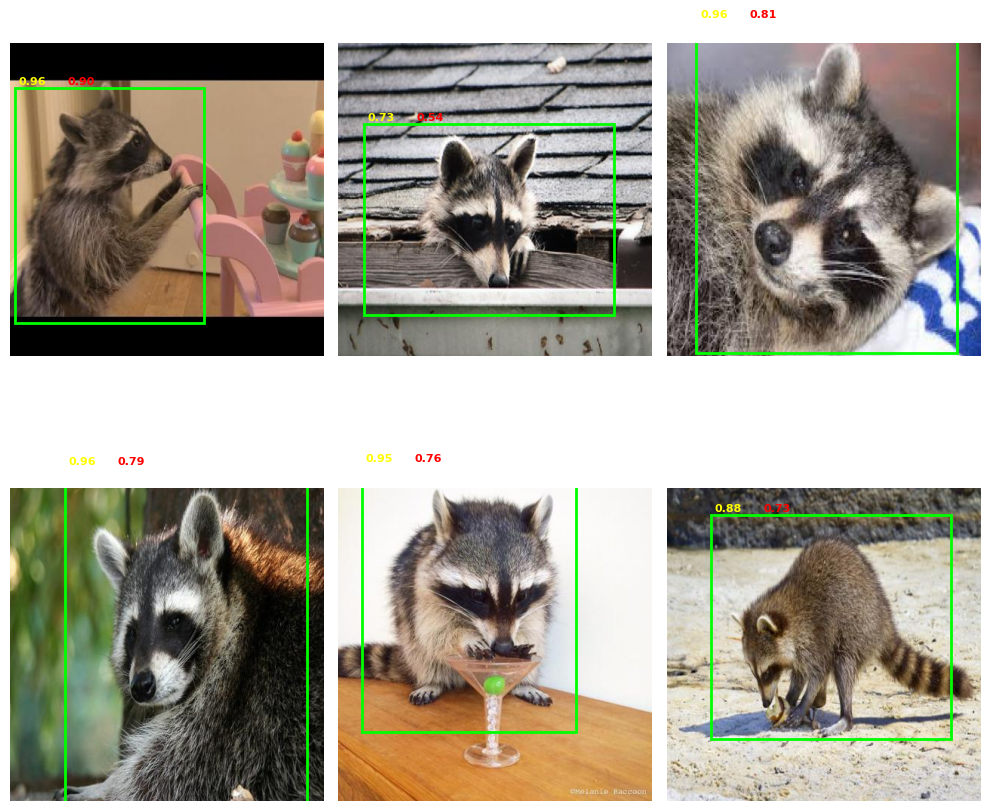

In [16]:
import random, cv2, torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = 'cuda'
model.eval()

# 1. выбираем 4 случайных индекса
ds = test_ds
idxs  = random.sample(range(len(ds)), 6)

# 2. готовим фигуру 2×3
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.ravel()

for ax, idx in zip(axes, idxs):

    # путь к изображению и само изображение
    img_path = ds.get_impath(idx)
    bgr      = cv2.imread(img_path)
    rgb      = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    H, W     = rgb.shape[:2]

    # True boxes
    _, t = ds[idx]
    gt_boxes = t['gt_boxes']

    # ---- инференс ----
    boxes, scores = predict(img_path, model, score_th=0.3)

    # IoU score
    iou_sc = 0
    for b1 in gt_boxes:
      for b2 in boxes:
        iou_sc = max(iou_sc,ds.compute_iou(b1,b2))

    # ---- рендер ----
    ax.imshow(rgb)
    ax.axis('off')

    for (x1, y1, x2, y2), sc in zip(boxes, scores):
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='lime',
                                 facecolor='none')
        ax.add_patch(rect)
        ax.text(x1+5, y1 - 5, f'{sc:.2f}', color='yellow',
                fontsize=8, weight='bold')

        ax.text(x1+70, y1 - 5, f'{iou_sc:.2f}', color='red',
                fontsize=8, weight='bold')

plt.tight_layout()
plt.show()

* yellow numbers are model's confidence scores

* red numbers are IoU scores with true bounding boxes

## Perfomance FasterRCNN from torchvision for comparison

In [17]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

tv_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
device = 'cuda'
in_features = tv_model.roi_heads.box_predictor.cls_score.in_features
tv_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)
tv_model.to(device)

for p in tv_model.backbone.parameters():
    p.requires_grad_(False)

params = [p for p in tv_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=5e-4)
lr_sched  = torch.optim.lr_scheduler.StepLR(optimizer,
                                            step_size=3, gamma=0.1)

In [18]:
def collate_frcnn(batch):
    """
    Приводит данные RaccoonDataset к формату:
        images  : list[Tensor[C,H,W]]   (float32 0..1)
        targets : list[Dict{boxes,labels}]
    Остальные поля (proposals, deltas …) игнорируются.
    """
    images, targets = [], []

    for img_np, meta in batch:
        # --- изображение в Tensor ---
        img = (torch.from_numpy(img_np)
                     .permute(2, 0, 1)          # HWC → CHW
                     .float() / 255.)           # 0‒1
        images.append(img)

        # --- GT-боксы ---
        boxes = meta['gt_boxes']                # Tensor[N,4] уже в пикселях
        labels = torch.ones((boxes.size(0),), dtype=torch.int64)  # «raccoon» = 1

        targets.append({'boxes': boxes, 'labels': labels})

    return images, targets

In [19]:
train_dl = DataLoader(train_ds,
                          batch_size=2,
                          shuffle=True,
                          num_workers=2,
                          collate_fn=collate_frcnn)

val_dl   = DataLoader(val_ds,
                      batch_size=2,
                      shuffle=True,
                      num_workers=2,
                      collate_fn=collate_frcnn)

for epoch in range(2):
    tv_model.train()
    tr_loss = 0
    for imgs, tgts in train_dl:
        imgs = list(i.to(device) for i in imgs)
        tgts = [{k: v.to(device) for k,v in t.items()} for t in tgts]

        losses = tv_model(imgs, tgts)            # ← возвращает dict
        loss   = sum(losses.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()

    lr_sched.step()
    print(f'E{epoch+1}: train {tr_loss/len(train_dl):.4f}')

    # ---- валидация (loss без градиентов) ----
    #model.eval()
    with torch.no_grad():
        val_loss = 0
        for imgs, tgts in val_dl:
            imgs = list(i.to(device) for i in imgs)
            tgts = [{k:v.to(device) for k,v in t.items()} for t in tgts]
            losses = tv_model(imgs, tgts)
            val_loss += sum(losses.values()).item()
    print(f'          val   {val_loss/len(val_dl):.4f}')

E1: train 0.1861
          val   0.0901
E2: train 0.1027
          val   0.0744


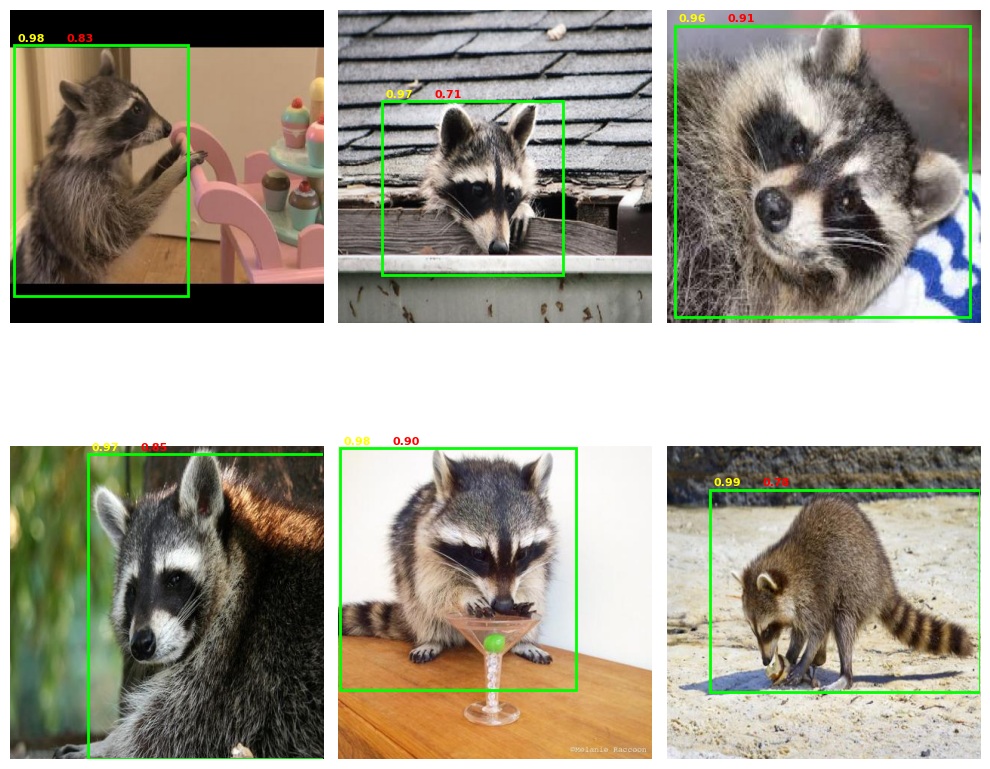

In [20]:
tv_model.eval()

# 2. готовим фигуру 2×3
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.ravel()

for ax, idx in zip(axes, idxs):

    # изображение
    rgb, t = ds[idx]
    gt_boxes = t['gt_boxes']
    H, W     = rgb.shape[:2]

    # ---- инференс ----
    inp = torch.from_numpy(rgb).permute(2,0,1).float()/255.
    with torch.no_grad():
        out = tv_model([inp.to(device)])[0]
    boxes = out['boxes'].cpu().numpy()[:1]
    scores = out['scores'].cpu().numpy()

    iou_sc = 0
    for b1 in gt_boxes:
      for b2 in boxes:
        iou_sc = max(iou_sc,ds.compute_iou(b1,b2))

    # ---- рендер ----
    ax.imshow(rgb)
    ax.axis('off')

    for (x1, y1, x2, y2), sc in zip(boxes, scores):
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='lime',
                                 facecolor='none')
        ax.add_patch(rect)
        ax.text(x1+5, y1 - 5, f'{sc:.2f}', color='yellow',
                fontsize=8, weight='bold')

        ax.text(x1+70, y1 - 5, f'{iou_sc:.2f}', color='red',
                fontsize=8, weight='bold')

plt.tight_layout()
plt.show()

* yellow numbers are model's confidence scores

* red numbers are IoU scores with true bounding boxes

## Conclusion
During training, I experimented with two backbones: one is vgg16 pre-trained on Imagenet and the other the same as in torchvision pre-trained on COCO. The second backbone produced much better results.

Data augmentation also made important contribution. Without it model were consistently overfitting.

Overall, it seems that my custom Fast R-CNN does not randomly predict boxes, however the torchvision Faster R-CNN model works better :(